<a href="https://colab.research.google.com/github/saikala0109/AI-12-Days-Bootcamp/blob/main/Day7_RAG_Chatbot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q chromadb sentence-transformers scikit-learn matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 67.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 100.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 79.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.8/71.8 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.9/170.9 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.3/61.3 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.7/203.7 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 3.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the 

In [2]:
from sentence_transformers import SentenceTransformer
from chromadb import PersistentClient

In [3]:
embed = SentenceTransformer(
    'sentence-transformers/all-MiniLM-L6-v2'
)

print(
    'Embedding dim:',
    embed.get_sentence_embedding_dimension()
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding dim: 384


/tmp/ipykernel_1867/3044651104.py:7: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  embed.get_sentence_embedding_dimension()


In [4]:
from sentence_transformers import SentenceTransformer

In [5]:
sample_text = """
Operating Systems: Process management, threads, scheduling algorithms.

Memory management: paging, segmentation, virtual memory.

File systems: directory structures, allocation methods.

Synchronization: semaphores, monitors, critical section.

Deadlocks: prevention, avoidance, recovery.

Database Management Systems: ER model, normalization.

SQL: joins, subqueries, triggers, views.

Transactions: ACID properties and concurrency control.

Indexing: B+ trees and hashing.

Computer Networks: TCP/IP and routing.
"""

with open("cse_sem5.txt", "w") as f:
    f.write(sample_text)

print("File created successfully")

File created successfully


In [6]:
with open('cse_sem5.txt') as f:
    text = f.read()

paragraphs = [
    p.strip()
    for p in text.split('\n\n')
    if p.strip()
][:10]

print(f'Loaded {len(paragraphs)} paragraphs')

for i, p in enumerate(paragraphs):

    print(f'[{i+1}] {p[:80]}')

Loaded 10 paragraphs
[1] Operating Systems: Process management, threads, scheduling algorithms.
[2] Memory management: paging, segmentation, virtual memory.
[3] File systems: directory structures, allocation methods.
[4] Synchronization: semaphores, monitors, critical section.
[5] Deadlocks: prevention, avoidance, recovery.
[6] Database Management Systems: ER model, normalization.
[7] SQL: joins, subqueries, triggers, views.
[8] Transactions: ACID properties and concurrency control.
[9] Indexing: B+ trees and hashing.
[10] Computer Networks: TCP/IP and routing.


In [7]:
client = PersistentClient(path='./chroma_db')

In [8]:
col = client.get_or_create_collection(
    'hello_syllabus'
)

print("Collection created")

Collection created


In [9]:
vectors = embed.encode(paragraphs).tolist()

print("Embeddings created")

Embeddings created


In [10]:
col.add(
    documents=paragraphs,
    embeddings=vectors,
    ids=[f'p{i}' for i in range(len(paragraphs))]
)

print(f'Indexed {col.count()} documents')

Indexed 10 documents


In [11]:
queries = [

    'operating system processes',

    'database normalization',

    'computer networks'
]

for q in queries:

    print(f'\nQuery: {q}')

    qv = embed.encode([q]).tolist()

    results = col.query(
        query_embeddings=qv,
        n_results=3
    )

    docs = results['documents'][0]

    distances = results['distances'][0]

    for j, (d, dist) in enumerate(zip(docs, distances)):

        print(
            f'[{j+1}] (dist={dist:.3f}) {d[:80]}'
        )


Query: operating system processes
[1] (dist=0.515) Operating Systems: Process management, threads, scheduling algorithms.
[2] (dist=1.216) Memory management: paging, segmentation, virtual memory.
[3] (dist=1.282) Transactions: ACID properties and concurrency control.

Query: database normalization
[1] (dist=0.642) Database Management Systems: ER model, normalization.
[2] (dist=1.324) SQL: joins, subqueries, triggers, views.
[3] (dist=1.352) Indexing: B+ trees and hashing.

Query: computer networks
[1] (dist=0.587) Computer Networks: TCP/IP and routing.
[2] (dist=1.367) Indexing: B+ trees and hashing.
[3] (dist=1.387) Operating Systems: Process management, threads, scheduling algorithms.


In [12]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

In [13]:
vectors_arr = np.array(vectors)

In [14]:
pca = PCA(n_components=2)

xy = pca.fit_transform(vectors_arr)

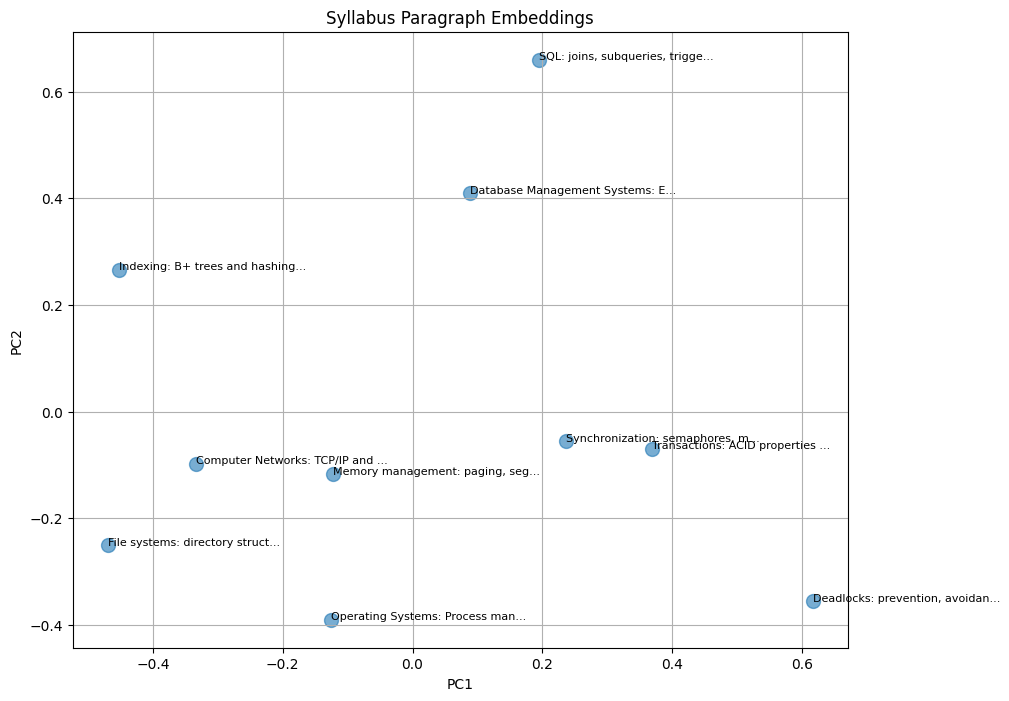

In [15]:
plt.figure(figsize=(10, 8))

plt.scatter(
    xy[:, 0],
    xy[:, 1],
    s=100,
    alpha=0.6
)

for i, p in enumerate(paragraphs):

    label = p[:30] + '...'

    plt.annotate(
        label,
        (xy[i, 0], xy[i, 1]),
        fontsize=8
    )

plt.title(
    'Syllabus Paragraph Embeddings'
)

plt.xlabel('PC1')

plt.ylabel('PC2')

plt.grid(True)

plt.show()

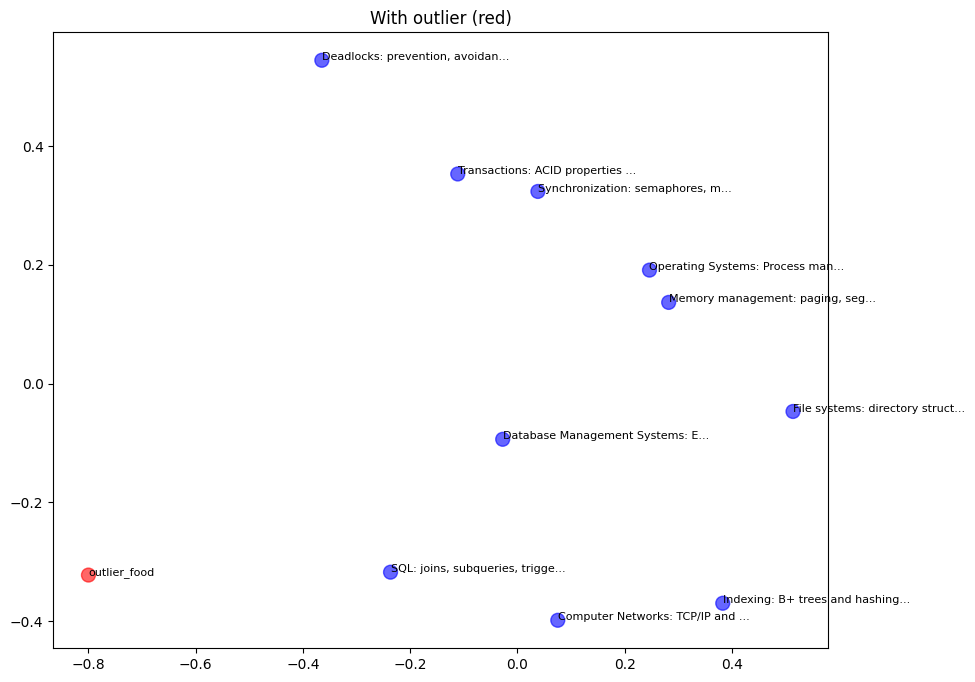

In [17]:

# Add a totally unrelated paragraph to see where it lands
outlier = "Today's special at the cafeteria is butter chicken with rice and naan."

col.add(
    documents=[outlier],
    embeddings=embed.encode([outlier]).tolist(),
    ids=['outlier_food']
)

# Re-fetch all and re-plot
all_docs = col.get(include=['embeddings', 'documents'])
all_vecs = np.array(all_docs['embeddings'])
labels = all_docs['ids']

pca = PCA(n_components=2) # Re-initialize PCA to ensure it fits the new data
xy = pca.fit_transform(all_vecs)
plt.figure(figsize=(10, 8))
colors = ['red' if 'outlier' in l else 'blue' for l in labels]
plt.scatter(xy[:, 0], xy[:, 1], c=colors, s=100, alpha=0.6)
for i, l in enumerate(labels):
    short = labels[i] if 'outlier' in labels[i] else all_docs['documents'][i][:30] + '...'
    plt.annotate(short, (xy[i, 0], xy[i, 1]), fontsize=8)
plt.title('With outlier (red)')
plt.show()

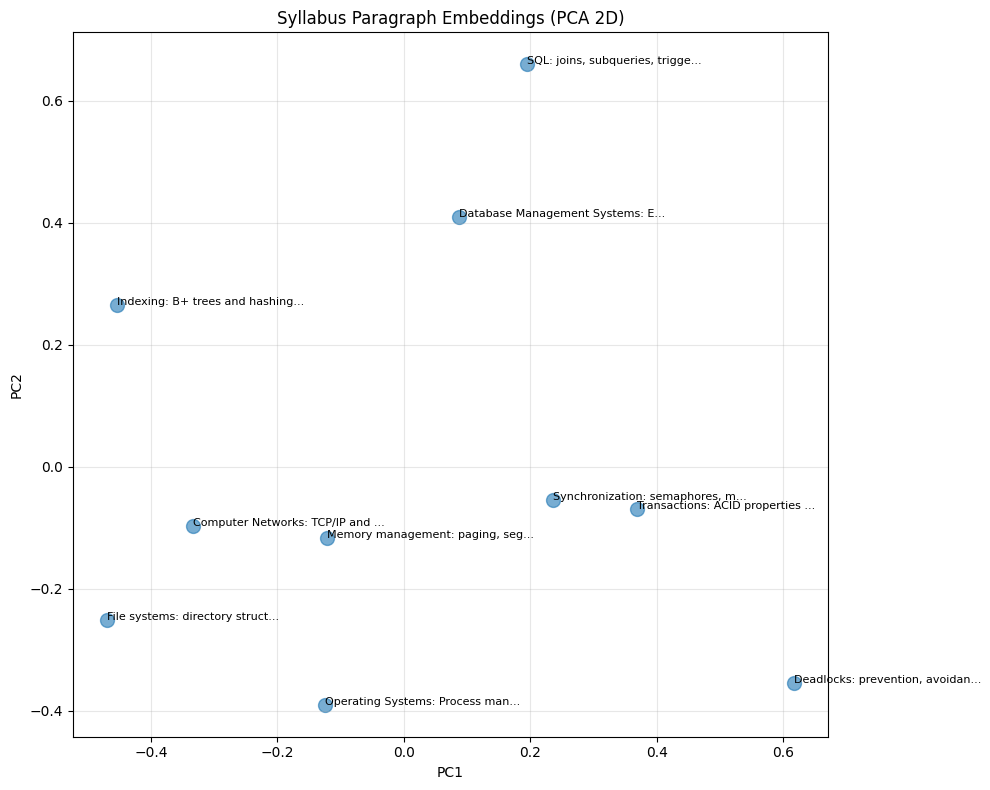

In [19]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

vectors_arr = np.array(vectors)

pca = PCA(n_components=2)
xy = pca.fit_transform(vectors_arr)

plt.figure(figsize=(10, 8))
plt.scatter(xy[:, 0], xy[:, 1], s=100, alpha=0.6)
for i, p in enumerate(paragraphs):
    label = p[:30] + '...' if len(p) > 30 else p
    plt.annotate(label, (xy[i, 0], xy[i, 1]), fontsize=8)
plt.title('Syllabus Paragraph Embeddings (PCA 2D)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()